### CFG Parsing Setup

Imports

In [34]:
from collections import defaultdict # For grammar and rule maps
import math # For potential numeric utilities
import pandas as pd # For tabular summaries
import matplotlib.pyplot as plt # For plotting
import seaborn as sns # For plot styling
from pathlib import Path # For reliable file-path handling

Set Grammar Structure

In [35]:
# Create grammar as a mapping: nonterminal -> list of productions.
grammar = defaultdict(list)

# Lexical Rules
grammar["PRON"].append(["я"]) # PRON -> "я"
grammar["VERB"].append(["вижу"]) # VERB -> "вижу"
grammar["NOUN"].append(["собаку"]) # NOUN -> "собаку"
grammar["DET"].append(["этот"]) # DET -> "этот"

# Phrase Structure Rules
grammar["S"].append(["NP", "VP"]) # Phrase rule: S -> NP VP
grammar["VP"].append(["VERB", "NP"]) # Phrase rule: VP -> VERB NP
grammar["NP"].append(["DET", "NOUN"]) # Phrase rule: NP -> DET NOUN
grammar["NP"].append(["PRON"]) # Unary phrase rule: NP -> PRON
grammar["NP"].append(["NOUN"]) # Unary phrase rule: NP -> NOUN

### CKY Parser

In [36]:
# Function to convert grammar into unary rule map for closure.
# Expand symbols in a chart cell using unary closure.
def apply_unary_closure(cell, unary_rules):
    # Start with current symbols in the cell.
    agenda = list(cell)
    # Keep expanding until no new unary parents appear.
    while agenda:
        # Pop one symbol to expand.
        symbol = agenda.pop()
        # Find all unary parents of the symbol.
        for parent in unary_rules.get(symbol, []):
            # Add unseen parent and continue closure search.
            if parent not in cell:
                cell.add(parent)
                agenda.append(parent)


Initialize CKY Table

In [37]:
# Parse a tokenized sentence with CKY using a CFG-like grammar.
def cky_parse(sentence, grammar):
    # Get sentence length.
    n = len(sentence)
    # Return empty table for empty input.
    if n == 0:
        return []

    # Build n x n CKY chart with sets in each cell.
    table = [[set() for _ in range(n)] for _ in range(n)]

    # Store lexical rules keyed by observed word.
    lexical_rules = defaultdict(list)
    # Store unary nonterminal rules keyed by child symbol.
    unary_rules = defaultdict(list)
    # Store binary rules keyed by (left_child, right_child).
    binary_rules = defaultdict(list)

    # Cache known nonterminals to separate lexical vs unary rules.
    nonterminals = set(grammar.keys())

    # Partition grammar rules by type/arity.
    for lhs, productions in grammar.items():
        # Process every RHS production for this LHS.
        for production in productions:
            # Handle unary production.
            if len(production) == 1:
                # Get unary RHS symbol.
                rhs = production[0]
                # If RHS is nonterminal, treat as unary grammar rule.
                if rhs in nonterminals:
                    unary_rules[rhs].append(lhs)
                # Otherwise treat RHS as lexical token.
                else:
                    lexical_rules[rhs].append(lhs)
            # Handle binary production.
            elif len(production) == 2:
                binary_rules[tuple(production)].append(lhs)

    # Fill chart diagonal from lexical matches.
    for i, word in enumerate(sentence):
        # Add all POS/nonterminals that can generate this word.
        for lhs in lexical_rules.get(word, []):
            table[i][i].add(lhs)
        # Apply unary closure to include derived categories.
        apply_unary_closure(table[i][i], unary_rules)

    # Fill spans from short to long.
    for span in range(2, n + 1):
        # Iterate all span start positions.
        for i in range(n - span + 1):
            # Compute span end index.
            j = i + span - 1

            # Try all split points for this span.
            for k in range(i, j):
                # Iterate left-child candidates.
                for B in table[i][k]:
                    # Iterate right-child candidates.
                    for C in table[k + 1][j]:
                        # Add parents that match rule A -> B C.
                        for A in binary_rules.get((B, C), []):
                            table[i][j].add(A)

            # Apply unary closure after binary combinations.
            apply_unary_closure(table[i][j], unary_rules)

    # Return complete CKY chart.
    return table

### Sentence Validation

In [38]:
# Function to check if sentence is grammatical based on CKY table
# Return True when top-right CKY cell contains start symbol S
def is_grammatical(table):
    # Guard against empty parse tables
    if not table:
        return False
    # Get chart dimension
    n = len(table)
    # Sentence is grammatical if S covers full span
    return "S" in table[0][n - 1]

### Toy Sentence Test

Run CKY on Controlled Example

In [39]:
# Define a toy Russian sentence to parse
sentence = ["я", "вижу", "собаку"]
# Run CKY parsing on the toy sentence
table = cky_parse(sentence, grammar)

# Print the sentence string
print(f"Sentence: {' '.join(sentence)}")
# Print whether full-span parse exists
print(f"Valid Parse: {is_grammatical(table)}")

Sentence: я вижу собаку
Valid Parse: True


Inspect Parse Table

In [40]:
# Iterate over row indices of the CKY chart
for i in range(len(sentence)):
    # Iterate over column indices of the CKY chart
    for j in range(len(sentence)):
        # Print only non-empty chart cells
        if table[i][j]:
            print(i, j, table[i][j])

0 0 {'PRON', 'NP'}
0 2 {'S'}
1 1 {'VERB'}
1 2 {'VP'}
2 2 {'NOUN', 'NP'}


### Evaluate on UD Dataset

Run on Sample Sentence

In [41]:

# Function to print CKY chart in a readable format
# Load tokenized sentences from a CoNLL-U file
def load_ud_sentences(conllu_path, max_sentences = None):
    # Initialize list for all extracted sentences
    sentences = []
    # Initialize token buffer for current sentence
    current = []

    # Open file using UTF-8 encoding
    with open(conllu_path, "r", encoding = "utf-8") as f:
        # Read file line by line
        for raw_line in f:
            # Remove leading/trailing whitespace
            line = raw_line.strip()

            # Detect sentence boundary (blank line)
            if not line:
                # Save buffered sentence if not empty
                if current:
                    sentences.append(current)
                    # Reset buffer for next sentence
                    current = []
                    # Stop early if max count reached
                    if max_sentences is not None and len(sentences) >= max_sentences:
                        break
                # Continue after handling boundary
                continue

            # Skip comment/metadata lines
            if line.startswith("#"):
                continue

            # Split CoNLL-U line into columns
            parts = line.split("\t")
            # Skip multiword or empty-node token IDs
            if not parts or "-" in parts[0] or "." in parts[0]:
                continue

            # Append normalized surface form from FORM column
            current.append(parts[1].lower())

    # Append last buffered sentence if file lacks trailing blank line
    if current and (max_sentences is None or len(sentences) < max_sentences):
        sentences.append(current)

    # Return list of tokenized sentences
    return sentences

In [42]:
# Choose how many UD sentences to sample
sample_size = 10
# Point to local UD Russian training file
ru_path = Path("ru_train.conllu")
# Load up to sample_size sentences
sentences = load_ud_sentences(ru_path, max_sentences = sample_size)
# Collect parse outcomes as booleans
results = []

In [43]:
# Parse each sampled sentence
for sentence in sentences:
    # Build CKY chart for current sentence
    table = cky_parse(sentence, grammar)
    # Determine if sentence has full parse
    parsed = is_grammatical(table)
    # Save parse outcome
    results.append(parsed)

    # Print sentence for inspection
    print(f"\nSentence: {' '.join(sentence)}")
    # Print parse success flag
    print(f"Parsed: {parsed}")


Sentence: во время битвы между силами магнето и героями , кто восстановил свои воспоминания , мутант лайла миллер смогла восстановить воспоминания магнето об оригинальной реальности .
Parsed: False

Sentence: когда он будет заполнен , у драконов появляется возможность перейти в режим ярости , силе которого не способен сопротивляться ни один противник в игре .
Parsed: False

Sentence: главная пара используется весь сезон и имеет значения 1 : 27454 , 1 : 41762 , 1 : 45717 и 1 : 42064 .
Parsed: False

Sentence: этим же постановлением устанавливалась окружная и районная система деления края .
Parsed: False

Sentence: позже вышел имеющий силу закона указ президента республики казахстан от 15 сентября 1995 г .
Parsed: False

Sentence: но в 1920 году он переехал во дворец дорн , где прожил до своей смерти в 1941 году .
Parsed: False

Sentence: придаток в мужском початке , сидячий , загнутый или закрученный , бледно-зелёный , в основании узкоцилиндрический , на вершине нитевидный , до 20 см д

Success Rate

In [44]:
# Compute success rate when results are available
if results:
    success_rate = sum(results) / len(results)
# Default to zero when no sentences were evaluated
else:
    success_rate = 0.0

# Print success percentage rounded to two decimals
print(f"CKY Success Rate: {round(success_rate * 100, 2)}%")

CKY Success Rate: 0.0%


### Visualization

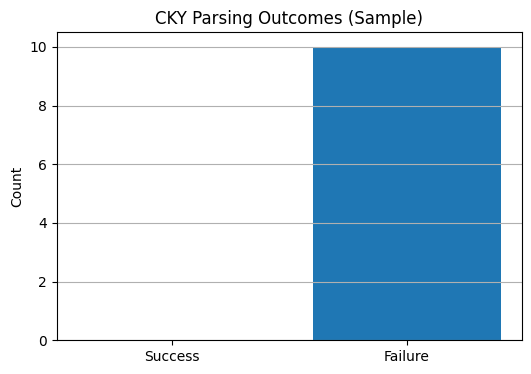

In [45]:
# Create figure for parse outcome distribution
plt.figure(figsize = (6,4))

# Draw bars for successful vs failed parses
plt.bar(
    ["Success", "Failure"],
    [sum(results), len(results) - sum(results)]
)

# Set plot title
plt.title("CKY Parsing Outcomes (Sample)")
# Label y-axis as count
plt.ylabel("Count")
# Add horizontal grid lines for readability
plt.grid(axis = "y")

# Render the figure
plt.show()

### Coverage Analysis

In [46]:
# Build a compact dictionary of parsing coverage metrics
coverage_stats = {
    # Total number of evaluated sentences
    "Total Sentences": len(results),
    # Number of sentences parsed successfully
    "Successful Parses": sum(results),
    # Number of sentences that failed to parse
    "Failed Parses": len(results) - sum(results),
    # Success percentage rounded to two decimals
    "Success Rate (%)": round(success_rate * 100, 2)
}

# Display the coverage summary dictionary
coverage_stats

{'Total Sentences': 10,
 'Successful Parses': 0,
 'Failed Parses': 10,
 'Success Rate (%)': 0.0}